# Notebook 6 — Template matching

*SWC ENC 2026 · ephys-pop module*

Clustering assigns each detected spike to one unit — but when two neurons fire almost
at once, their waveforms **add** into a shape that belongs to neither, and detection
either mislabels it or misses one of the two. **Matching pursuit** fixes this. Armed
with the templates from Notebook 5, it explains the trace as a **sum of templates**,
peeling them off one at a time, so overlapping spikes are separated.

**In this notebook you will:**
1. See a **collision** that clustering gets wrong.
2. Build the **matched filter**: how well does a template fit at a given time?
3. Run **matching pursuit** — greedily subtract the best-fitting template — and watch
   the residual melt away.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

rec = ps.make_recording(n_units=6, duration_s=20.0, seed=0)
whitened, filtered, W = ps.preprocess(rec)
# Reuse the pipeline through clustering to get templates (built in Notebook 5).
res = ps.run_picosort(rec)
templates = res.templates
print(f"{len(templates)} templates, each {templates.shape[1]}×{templates.shape[2]} (channels×samples)")

6 templates, each 32×61 (channels×samples)


## 1. A collision

Find a moment where two true spikes from different units land within a fraction of a
millisecond. Their waveforms superimpose — the recorded trace is the **sum**, not
either template alone. A single-label method has to pick one unit and gets the other
wrong.

collision at 5.477s: units 3 and 2, 9 samples apart


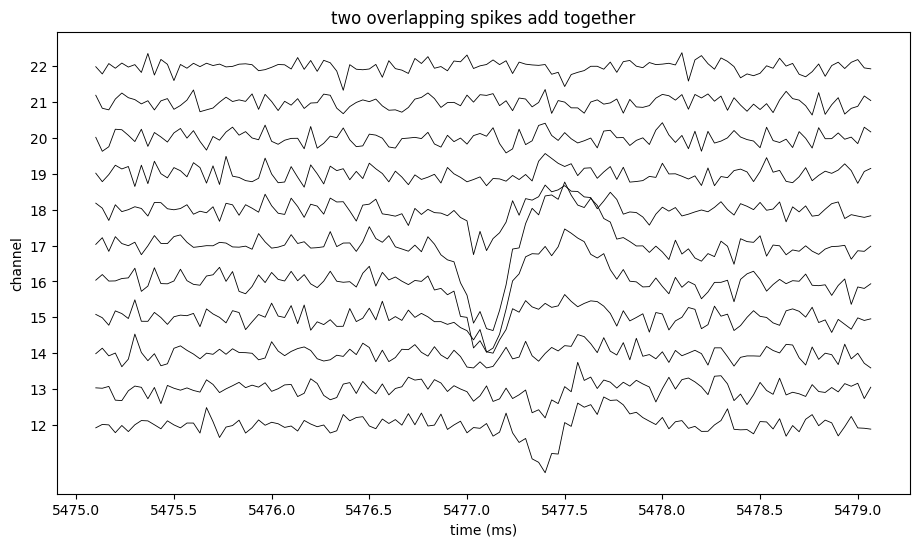

In [2]:
gt = rec.ground_truth
order = np.argsort(gt.spike_times)
st, sl = gt.spike_times[order], gt.spike_labels[order]
gaps = np.diff(st)
i = np.where((gaps > 0) & (gaps < 20) & (sl[:-1] != sl[1:]))[0][0]  # <~0.7 ms apart, different units
t_col = st[i]
print(f"collision at {t_col/rec.fs:.3f}s: units {sl[i]} and {sl[i+1]}, {gaps[i]} samples apart")

pc = ps.peak_channel(gt.templates[sl[i]])
ps.plotting.plot_signal(filtered, rec.fs, channels=range(max(0, pc-5), pc+6),
                        t0=(t_col-60)/rec.fs, t1=(t_col+60)/rec.fs,
                        title="two overlapping spikes add together")
plt.show()

## 2. The matched filter

**How do you find a known shape hidden in a signal?** You **slide** a copy of it along
and, at each position, measure how well the two line up — by multiplying them
point-by-point and adding up. That sum is the **dot product** (a *correlation*): it's
large where the signal looks like the shape and small where it doesn't. Watch it locate
a waveform dropped into pure noise:

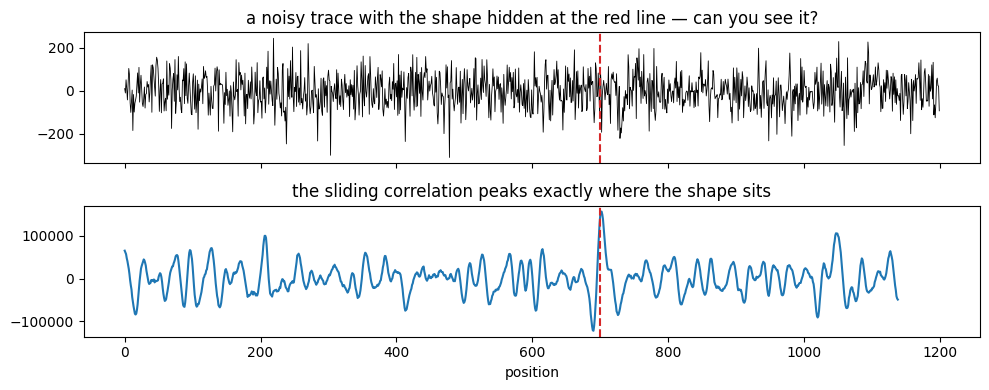

In [3]:
rng = np.random.default_rng(0)
shape = templates[0][ps.peak_channel(templates[0])]      # one template's peak-channel waveform
L = len(shape)
trace = rng.normal(0, shape.std() * 1.5, 1200)           # pure noise ...
loc = 700
trace[loc:loc + L] += shape                              # ... with the shape hidden at t=700

corr = np.array([np.dot(trace[i:i + L], shape) for i in range(len(trace) - L)])

fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].plot(trace, "k", lw=0.6); ax[0].axvline(loc, color="tab:red", ls="--")
ax[0].set_title("a noisy trace with the shape hidden at the red line — can you see it?")
ax[1].plot(corr, "tab:blue"); ax[1].axvline(loc, color="tab:red", ls="--")
ax[1].set_title("the sliding correlation peaks exactly where the shape sits")
ax[1].set_xlabel("position"); plt.tight_layout(); plt.show()

Even though the shape is invisible to the eye in the raw trace, the sliding correlation
spikes precisely where it sits. That sliding dot product **is** the matched filter, and
it's how we find each unit's spikes: correlate the recording with a unit's template,
and the peaks are its spike times.

One refinement turns the raw correlation into an actual *amplitude* — how big a copy of
the template fits. How well does template $j$ fit the trace at time $t$? Slide it there,
take the **inner product** with the trace window, and normalise. The best-fitting
amplitude is

$$a \;=\; \frac{\langle \text{trace window},\ \text{template}_j\rangle}{\lVert \text{template}_j\rVert^2}.$$

An $a$ near 1 means the template fits at full size — a spike of unit $j$ is there. The
**score** (how much subtracting it reduces the leftover error) is $a^2\lVert
\text{template}_j\rVert^2$.

<details>
<summary><b>▸ Go deeper: where these formulas come from (optional)</b></summary>

**The amplitude is least squares.** Model the trace window as a scaled template plus
noise, $x = a\,s + \text{noise}$, and pick $a$ to minimise the squared error
$\lVert x - a s\rVert^2$. Setting the derivative to zero,
$\frac{d}{da}\lVert x - as\rVert^2 = -2\,\langle x, s\rangle + 2a\lVert s\rVert^2 = 0$,
gives

$$a = \frac{\langle x, s\rangle}{\lVert s\rVert^2}.$$

Substituting back, the error *drops* by exactly $a^2\lVert s\rVert^2$ — that's the
**score**, so "best score" = "explains the most trace."

**Why correlation is the right detector.** Among all linear filters $w$, which one
best flags the presence of $s$ in white noise? Maximising the signal-to-noise ratio
$\langle w, s\rangle^2 / \lVert w\rVert^2$ is answered by the **Cauchy–Schwarz
inequality**: it's largest when $w \propto s$. So the optimal detector *is*
correlation with the template — the **matched filter**. (If the noise is coloured
with covariance $C$, the optimum becomes $w \propto C^{-1}s$ — matched filtering on
*whitened* data, which is exactly why Notebook 2 whitened first.)

**Matching pursuit is greedy sparse coding.** We're approximating the whole recording
as a sparse sum of templates, $x \approx \sum_i a_i\, s_{k_i}(t - \tau_i)$ — ideally
the fewest spikes that explain the trace. Finding the truly sparsest set is
NP-hard, so matching pursuit takes the **greedy** route: repeatedly add the single
(template, time) with the largest score, subtract it, and recurse on the residual.
Each step is the least-squares fit above; peeling in order of score is what lets it
separate two overlapping spikes that a single-label clusterer cannot.
</details>

**Exercise 1** *(~6 min)*. Complete `fit_amplitude`: given a trace window and a template
(both `(n_channels, n_samples)`), return $a$.

> **Check / unstuck.** At the collision, the true unit's template should fit with
> $a \approx 1$. Stuck? $a = \sum(\text{window} \cdot \text{template}) / \sum(\text{template}^2)$.

In [4]:
half = templates.shape[2] // 2

def fit_amplitude(window, template):
    return np.sum(window * template) / np.sum(template ** 2)

# match the true unit's template at the collision (map true unit -> learned template)
tmpl_id = int(np.argmax([np.corrcoef(templates[a].ravel(), gt.templates[sl[i]].ravel())[0,1]
                         for a in range(len(templates))]))
window = filtered[t_col - half:t_col + half + 1].T           # (channels, samples)
a = fit_amplitude(window, templates[tmpl_id])
print(f"template {tmpl_id} fits at the collision with amplitude a = {a:.2f}")

template 4 fits at the collision with amplitude a = 0.98


## 3. Greedy peeling

Matching pursuit repeats one idea until nothing fits well:

1. over all templates and all times, find the **best** fit (largest score),
2. **subtract** that scaled template from the trace, and record a spike,
3. repeat on the leftover **residual**.

Each subtraction removes one spike — including one member of a collision, so the
other is exposed on the next pass. `ps.matching_pursuit` runs this efficiently over
the whole recording. Watch the residual energy fall as spikes are peeled off:

matching pursuit found 398 spikes


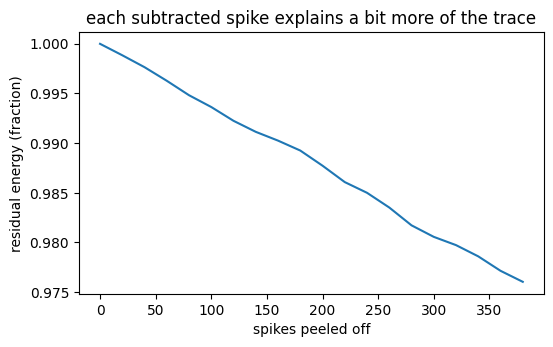

In [5]:
spike_times, spike_labels, spike_amps = ps.matching_pursuit(filtered, templates, amp_threshold=0.5)
print(f"matching pursuit found {len(spike_times)} spikes")

# residual energy: how much of the trace is left unexplained as we add spikes back
recon = np.zeros_like(filtered)
half = templates.shape[2] // 2
total = np.sum(filtered ** 2)
resid_energy = []
for n, (t, lab, a) in enumerate(zip(spike_times, spike_labels, spike_amps)):
    recon[t - half:t + half + 1] += a * templates[lab].T
    if n % 20 == 0:
        resid_energy.append(np.sum((filtered - recon) ** 2) / total)
plt.figure(figsize=(6, 3.4))
plt.plot(np.arange(len(resid_energy)) * 20, resid_energy)
plt.xlabel("spikes peeled off"); plt.ylabel("residual energy (fraction)")
plt.title("each subtracted spike explains a bit more of the trace"); plt.show()

## 4. The collision, resolved

Back to the collision. Matching pursuit should have placed **both** spikes — one of
each unit — where clustering could label only one. Overlay the reconstruction
(sum of the fitted templates) on the real trace at that moment:

matching pursuit placed 2 spikes at the collision: units [np.int64(4), np.int64(1)]


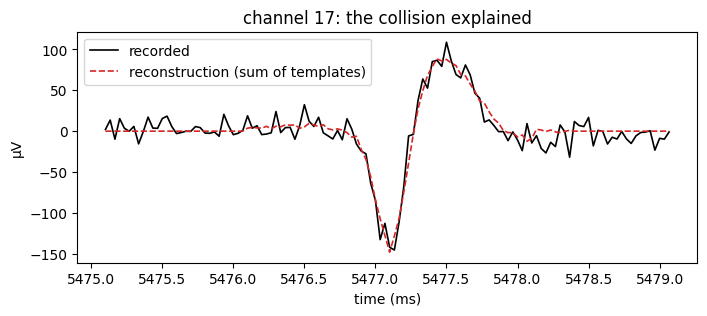

In [6]:
near = spike_times[np.abs(spike_times - t_col) < 15]
near_lab = spike_labels[np.abs(spike_times - t_col) < 15]
print(f"matching pursuit placed {len(near)} spikes at the collision: units {list(near_lab)}")

pc = ps.peak_channel(gt.templates[sl[i]])
fig, ax = plt.subplots(figsize=(8, 3))
w = slice(t_col - 60, t_col + 60)
tt = np.arange(w.start, w.stop) / rec.fs * 1e3
ax.plot(tt, filtered[w, pc], "k", lw=1.2, label="recorded")
ax.plot(tt, recon[w, pc], "tab:red", lw=1.2, ls="--", label="reconstruction (sum of templates)")
ax.set_xlabel("time (ms)"); ax.set_ylabel("µV"); ax.set_title(f"channel {pc}: the collision explained")
ax.legend(); plt.show()

The reconstruction tracks the recorded trace through the collision: both spikes are
accounted for. That's the payoff of template matching over plain clustering.

## Wrap-up

Matching pursuit turned the templates into a full list of spike times and labels,
pulling apart overlaps that clustering alone could not. We now have a complete sort.

**Next (Notebook 7 — cleanup):** not every unit the sorter returns is real. We use
**refractory periods** and **correlograms** to catch units that should be merged.